## Practical MCMC

### Autocorrelation, ESS, and Thinning



When running a Markov Chain Monte Carlo (MCMC) algorithm, each proposed step fundamentally depends on the previous one. Because of this inherent memory, a chain of $N$ steps does not actually contain $N$ independent pieces of information. To evaluate the true statistical power of our sampling, we rely on the following diagnostic concepts:

**1. Integrated Autocorrelation Time ($\tau$)**
The autocorrelation time, $\tau$, measures the "memory" or "stickiness" of the Markov chain. It represents the number of consecutive steps the algorithm must take before it completely "forgets" its previous position and produces a new, statistically independent sample from the posterior distribution. A highly correlated chain (often caused by a poorly tuned proposal distribution) will have a large $\tau$, meaning it explores the parameter space inefficiently.

**2. Effective Sample Size (ESS)**
The ESS quantifies the actual number of independent, identically distributed (i.i.d.) samples contained within your correlated MCMC chain. It is the true measure of your resolving power and sampling accuracy. If you run a chain for $N$ total steps, the Effective Sample Size is calculated as:

$$\text{ESS} = \frac{N}{\tau}$$

**3. Thinning**
Thinning is a data handling technique used to manage the massive memory footprint of long MCMC chains. If $\tau = 50$, storing every single step on your hard drive is heavily redundant because adjacent steps are highly correlated. Thinning a chain by a factor of $k$ means you only save every $k$-th sample (often choosing $k \approx \tau$) and discard the rest. This results in a much lighter, completely independent set of samples without sacrificing any meaningful statistical information.

**NB** Different samplers suffer the autocorrelation problem in different ways. *Ensemble sampler* implementing the *stretch move* allows to reduce the impact of this problem, with respect to the metropolis-hastings algorithm.


### Python MCMC Libraries: `emcee` vs `PyMC`

**1. `emcee` (The "Black-Box" Approach)**
* **Algorithm:** *Affine-Invariant Ensemble Sampler*. Uses a group of "walkers" that explore the parameter space by coordinating with each other.
* **How it works:** Treats the physics as a closed box. It only requires an arbitrary Python function that takes parameters as input and returns a single log-probability value.
* **Pros:** Absolute flexibility. Very easy to implement and interfaces perfectly with complex external physical simulators (ODE integrators, C/Fortran libraries).
* **Cons:** Inefficient on high-dimensional problems (starts struggling beyond ~50 parameters).

**2. `PyMC` (The "White-Box" Approach)**
* **Algorithm:** *Hamiltonian Monte Carlo (HMC)* with *NUTS*. Exploits mathematical gradients (slopes) to directionally "slide" toward probability peaks.
* **How it works:** Builds an exact probabilistic graph using the *PyTensor* framework, which allows the library to automatically calculate derivatives (Autodiff).
* **Pros:** Unmatched mathematical efficiency and speed. Effortlessly handles thousands of parameters with a very high acceptance rate.
* **Cons:** Steep learning curve and extremely difficult to make it communicate with "black-box" external physical simulators.

### Gibbs Sampling

In the framework of how to sample a posterior, alongside with ensamble sampler (use in emcee) and hamiltonian monte carlo (used in pymc), we found Gibbs.\
It is an alternative to gradient-based samplers like HMC, functioning as an extreme "white-box" approach: it requires direct analytical knowledge of the underlying 1D full conditional posterior distribution for each parameter, given the current values of all other parameters and the data.

* By drawing directly from the posterior conditionals, the **acceptance rate is 100%**.
* It's also **fast**; sequential draws directly from the parameter posterior conditionals means that we are not rejecting any points but becomes extremly low if features are higly corelated..
* You need to know the form of the **conditional probability** distributions for each parameter (or parameter blocks), and how to draw samples from it.
This can be a non-trivial problem, so typically a lot of effort is placed in manipulating the form of the posterior to find a conditional that is a standard probability distribution. This is where **conjugate priors** become really handy.

## The Transient Universe

This is a (100 x 3) numpy array, containing some time-series measurements from a transient phenomenon. The first column is time (arbitrary units), the second column is the flux (arbitrary units), and the third column are homoescedastic measurement uncertainties on the flux. Plot this data with the uncertainties.

In [5]:
import numpy as np
import emcee
import matplotlib.pyplot as plt
data = np.load("transient.npy")
time, flux, error = data.T

In [6]:
def Model(t, b, A, alpha, t0):
    return np.where(t < t0, b, b + A * np.exp(-alpha * (t - t0)))

def logLikelihood(theta, t, flux, error):
    b, A, alpha, t0 = theta
    model = Model(t, b, A, alpha, t0)
    logL = -0.5 * np.sum(((flux - model) / error) ** 2)
    return logL

def logPrior(theta):
    b, A, alpha, t0 = theta  
    #Il controllo np.exp(-5) < alpha < np.exp(5) garantisce matematicamente che alpha sia un numero strettamente positivo.
    if 0 < b < 50 and 0 < A < 50 and np.exp(-5) < alpha < np.exp(5) and 0 < t0 < 100:
        return -np.log(alpha)         
    return -np.inf

def logPosterior(theta, t, flux, error):
    logP = logPrior(theta)
    if not np.isfinite(logP):
        return -np.inf
    return logP + logLikelihood(theta, t, flux, error)

### MCMC con emcee, no burn-in, no thinnin

In [7]:
from torch import nested
ndim = 4
nwalkers = 50
nsteps = 15000

stretch_factor = emcee.moves.StretchMove(a=2.5)
try_sampler = emcee.EnsembleSampler(nwalkers, ndim, logPosterior, moves=stretch_factor, args=(time, flux, error))
initial_pos = np.array([10, 10, 0.1, 50]) + 1e-4 * np.random.randn(nwalkers, ndim)
try_sampler.run_mcmc(initial_pos, nsteps, progress=True);


100%|██████████| 15000/15000 [00:14<00:00, 1020.95it/s]


In [8]:
full_chain = try_sampler.get_chain()

/var/folders/df/8kzdlh4s5fb1h6n2cfc7y5fw0000gn/T/ipykernel_46500/2996507782.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[-1].legend(loc="upper right", ncol=4, frameon=True, fontsize=9)


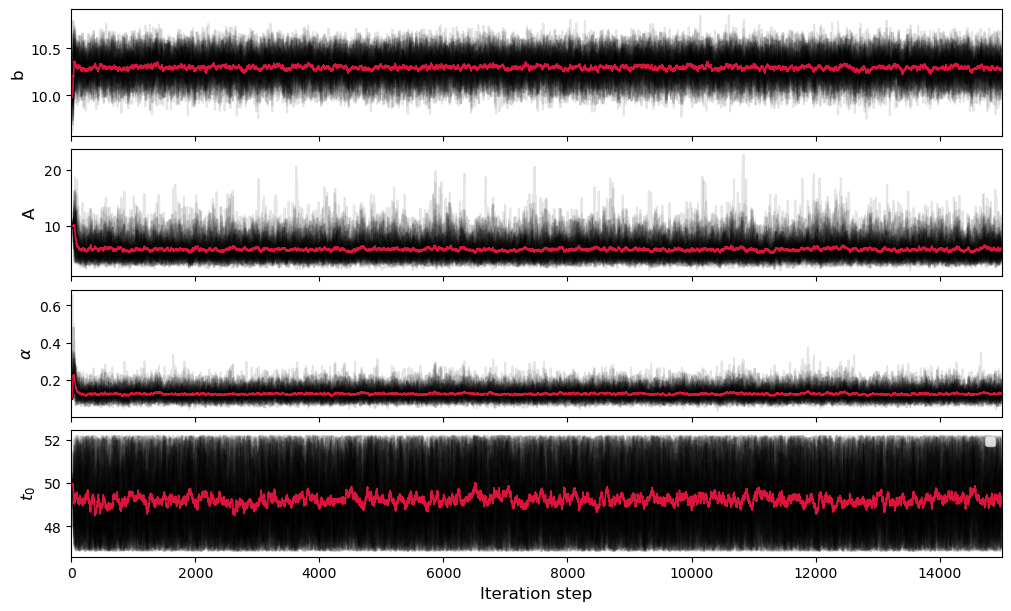

In [9]:
labels = ["b", "A", r"$\alpha$", "$t_0$"]
fig, axes = plt.subplots(ndim, figsize=(10, 6), sharex=True, constrained_layout=True)

for i, (ax, lbl) in enumerate(zip(axes, labels)):  
    #all walkers traces
    ax.plot(full_chain[:, :, i], "k", alpha=0.1, rasterized=True)
    #ensamble mean
    ax.plot(np.mean(full_chain[:, :, i], axis=1), "crimson", lw=1.2, label="Ensemble Mean" if i==0 else "")
    ax.set_ylabel(lbl, fontsize=12)
    ax.set_xlim(0, len(full_chain))

axes[-1].legend(loc="upper right", ncol=4, frameon=True, fontsize=9)
axes[-1].set_xlabel("Iteration step", fontsize=12)
plt.show()

Stampiamo acceptance fraction e autocorrelation time.

In [10]:
acc_frac = try_sampler.acceptance_fraction
media_acc = np.mean(acc_frac)
print(f"Mean acceptance fraction: {media_acc:.3f}")

tau = try_sampler.get_autocorr_time(tol=0)
print(f"$Tau$ of each parameter: {tau}")
tau_max = int(np.max(tau))

Mean acceptance fraction: 0.439
$Tau$ of each parameter: [50.62479574 67.46250803 52.6179035  67.43263341]



Risultati dell'Inferenza (Mediana ed Errori 1-sigma):
Parametro 0: 10.2971 (+0.1210 / -0.1251)
Parametro 1: 5.4484 (+1.8590 / -1.2743)
Parametro 2: 0.1228 (+0.0295 / -0.0237)
Parametro 3: 49.0822 (+1.9435 / -1.5642)


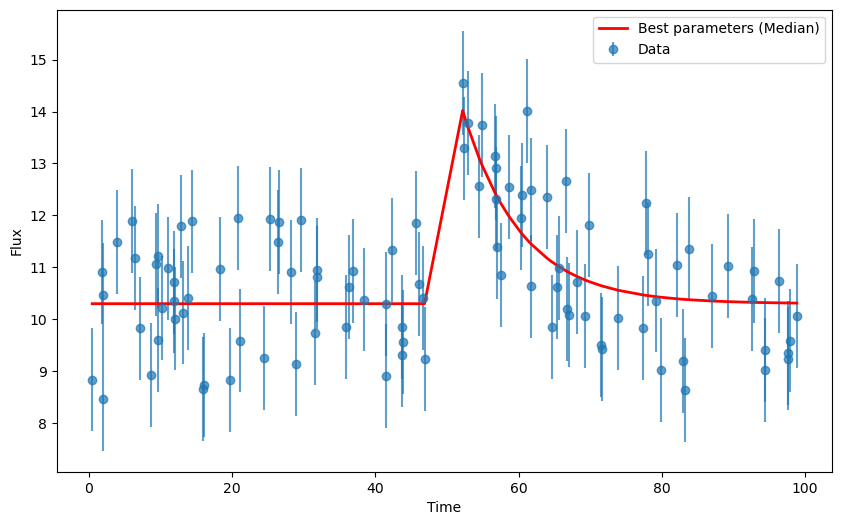

In [11]:
samples = try_sampler.get_chain(flat=True)
best_params = np.median(samples, axis=0)
p16 = np.percentile(samples, 16, axis=0)
p84 = np.percentile(samples, 84, axis=0)

# Calcolo delle incertezze asimmetriche
err_inf = best_params - p16
err_sup = p84 - best_params

print("\nRisultati dell'Inferenza (Mediana ed Errori 1-sigma):")
for i, (val, e_inf, e_sup) in enumerate(zip(best_params, err_inf, err_sup)):
    print(f"Parametro {i}: {val:.4f} (+{e_sup:.4f} / -{e_inf:.4f})")

plt.figure(figsize=(10, 6))
plt.errorbar(time, flux, yerr=error, fmt='o', label='Data', alpha=0.7)
model_flux = Model(time, *best_params)
plt.plot(time, model_flux, 'r-', label='Best parameters (Median)', linewidth=2)

plt.xlabel('Time')
plt.ylabel('Flux')
plt.legend()
plt.show()

### MCMC con emcee, burn-in e thinnin

Accettazione media: 0.439 | Tau max: 67.5


/var/folders/df/8kzdlh4s5fb1h6n2cfc7y5fw0000gn/T/ipykernel_46500/236739177.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[-1].legend(loc="upper right", ncol=4, frameon=True, fontsize=9)


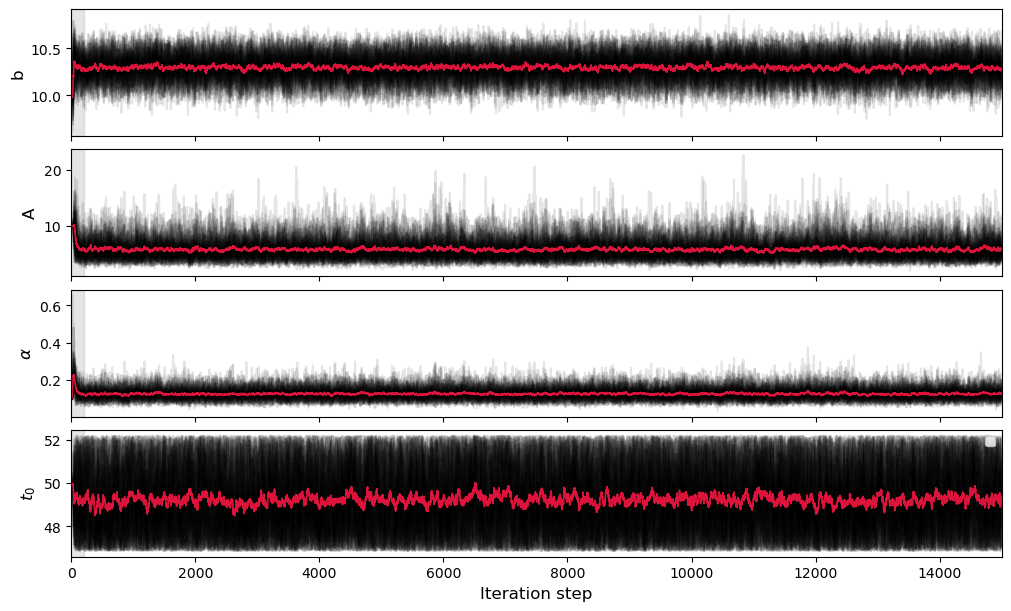

In [12]:
tau_max = np.max(try_sampler.get_autocorr_time(tol=0))
burn_in, thin = int(3 * tau_max), int(tau_max + 1)
print(f"Accettazione media: {np.mean(try_sampler.acceptance_fraction):.3f} | Tau max: {tau_max:.1f}")

full_chain = try_sampler.get_chain()
quantiles = np.percentile(try_sampler.get_chain(discard=burn_in, thin=thin, flat=True), [16, 50, 84], axis=0)

labels = ["b", "A", r"$\alpha$", "$t_0$"]
fig, axes = plt.subplots(ndim, figsize=(10, 6), sharex=True, constrained_layout=True)

for i, (ax, lbl) in enumerate(zip(axes, labels)):  
    #all walkers traces
    ax.plot(full_chain[:, :, i], "k", alpha=0.1, rasterized=True)
    #ensamble mean
    ax.plot(np.mean(full_chain[:, :, i], axis=1), "crimson", lw=1.2, label="Ensemble Mean" if i==0 else "")
    # Maschera del burn-in
    ax.axvspan(0, burn_in, color="gray", alpha=0.2, label="Burn-in" if i==0 else "")
    ax.set_ylabel(lbl, fontsize=12)
    ax.set_xlim(0, len(full_chain))

axes[-1].legend(loc="upper right", ncol=4, frameon=True, fontsize=9)
axes[-1].set_xlabel("Iteration step", fontsize=12)
plt.show()


Risultati dell'Inferenza (Mediana ed Errori 1-sigma):
Parametro 0: 10.2981 (+0.1184 / -0.1277)
Parametro 1: 5.4423 (+1.8322 / -1.2506)
Parametro 2: 0.1225 (+0.0295 / -0.0234)
Parametro 3: 49.0682 (+1.9655 / -1.5584)


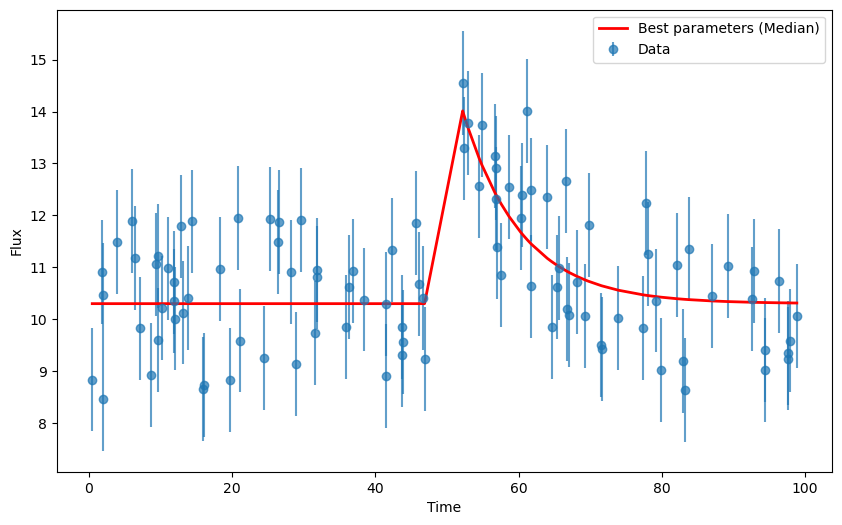

In [13]:
# Estrazione robusta dei parametri tramite mediana e percentili (16° e 84°)
ess = try_sampler.get_chain(discard=burn_in, thin=thin, flat=True)

p16, best_params, p84 = quantiles
# Calcolo delle incertezze asimmetriche
err_inf = best_params - p16
err_sup = p84 - best_params

print("\nRisultati dell'Inferenza (Mediana ed Errori 1-sigma):")
for i, (val, e_inf, e_sup) in enumerate(zip(best_params, err_inf, err_sup)):
    print(f"Parametro {i}: {val:.4f} (+{e_sup:.4f} / -{e_inf:.4f})")

plt.figure(figsize=(10, 6))
plt.errorbar(time, flux, yerr=error, fmt='o', label='Data', alpha=0.7)
model_flux = Model(time, *best_params)
plt.plot(time, model_flux, 'r-', label='Best parameters (Median)', linewidth=2)

plt.xlabel('Time')
plt.ylabel('Flux')
plt.legend()
plt.show()

### Confronto l'esplorazione della posterior con e senza thinnin

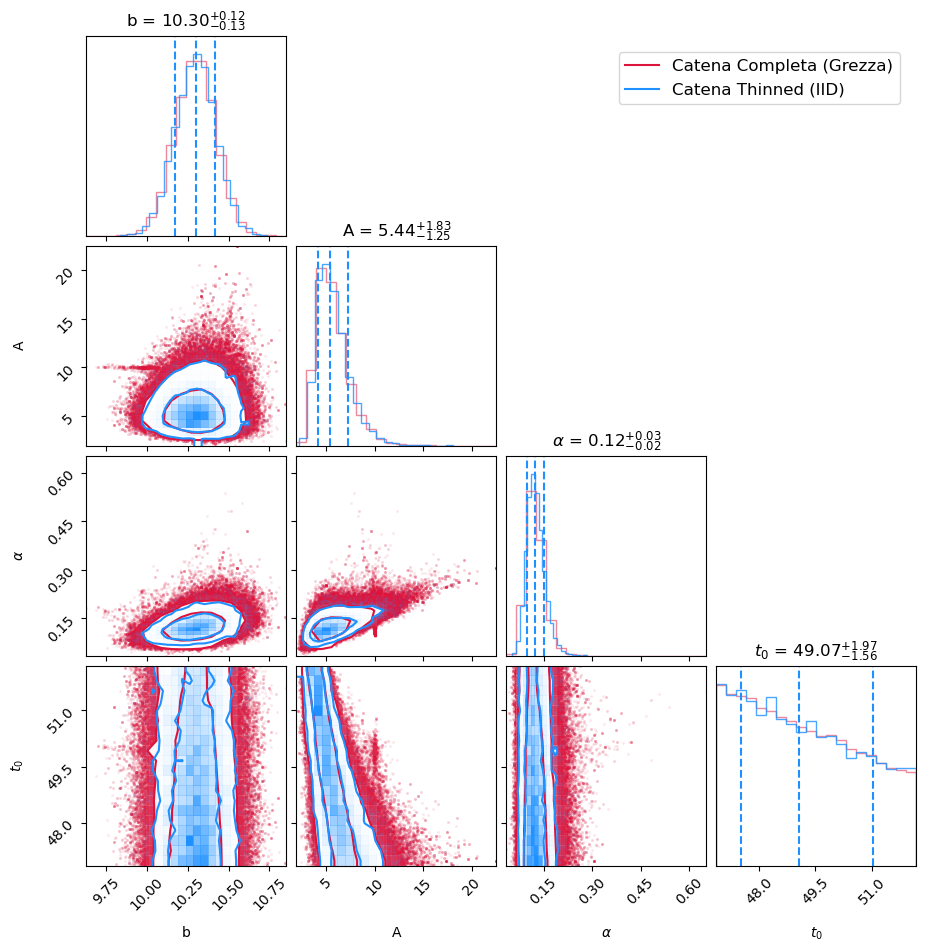

In [ ]:
import corner
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

#Catena grezza (con burn-in e correlazioni) in rosso
fig = corner.corner(
    samples, 
    labels=labels, 
    color="crimson",
    levels=[0.68, 0.95],
    #hist_kwargs={'density': True} assicura che gli istogrammi siano confrontabili anche se 'samples' ha molti più punti di 'ess'
    hist_kwargs={'density': True, 'alpha': 0.5} 
)

#Catena pulita (no burn-in, thinned) in blu, passandole 'fig=fig'
corner.corner(
    ess, 
    fig=fig,                 
    labels=labels, 
    color="dodgerblue",
    levels=[0.68, 0.95],
    quantiles=[0.16, 0.5, 0.84], 
    show_titles=True,
    hist_kwargs={'density': True, 'alpha': 0.8}
)

#Aggiunta di una legenda manuale per distinguere le due catene
red_line = mlines.Line2D([], [], color='crimson', label='Catena Completa (Grezza)')
blue_line = mlines.Line2D([], [], color='dodgerblue', label='Catena Thinned (IID)')
fig.legend(handles=[red_line, blue_line], loc='upper right', fontsize=12, bbox_to_anchor=(0.95, 0.95))

plt.show()